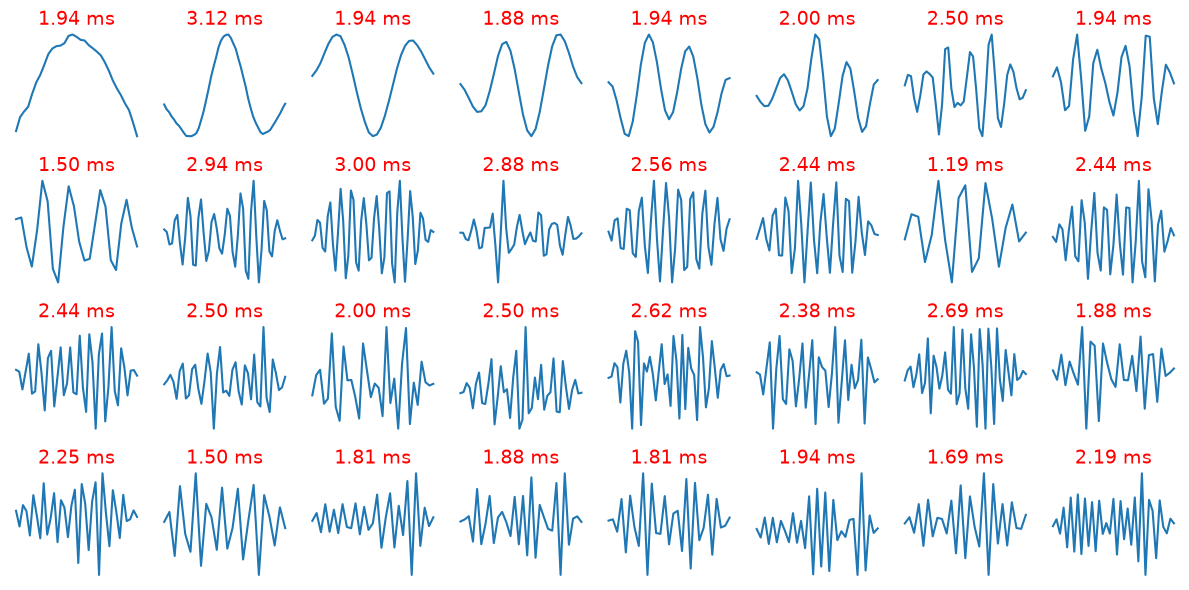

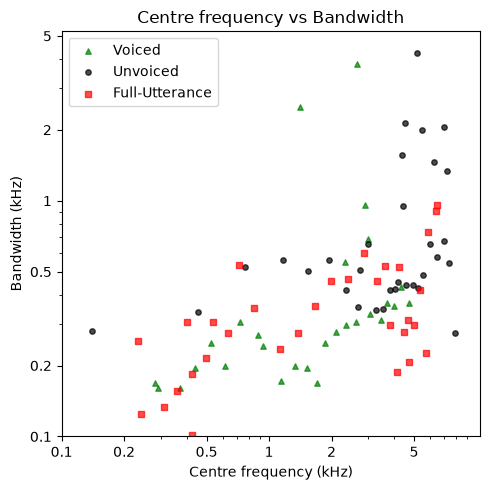

In [23]:
import sys
import os

import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
from utils_python import mp_utils as mp # matching pursuit stuff
from utils_python import filter_utils as fu # matching pursuit stuff

import librosa # common audio processing library
import IPython.display as ipd # For playing audio

fs = 16000

y, fs_audio = librosa.load("jupyter-notebook/SA1.WAV", sr=None)
if fs_audio != fs:
    print('Invalid sampling rate')
y = y/np.max(np.abs(y)) 
# ipd.Audio(y, rate=fs)

unvoiced_ex_dictionary = mp.create_dictionary_from_JLD2("ResultsUNVOICED/epoch_6.jld2")
voiced_dictionary = mp.create_dictionary_from_JLD2("ResultsVOICED/epoch_6.jld2")
normal_dictionary = mp.create_dictionary_from_JLD2("ResultsNORMAL/epoch_6.jld2")
sorted = mp.sort_dictionary(unvoiced_ex_dictionary)
mp.plot_dictionary_elements(sorted, sample_rate=fs)

# print("Running matching pursuit. This might take a while...")
# y_enc, y_res = mp.matching_pursuit(unvoiced_ex_dictionary, y, "abs_amplitude", 0.03) # encode with amplitude as stopping condition
# print("Running matching pursuit finished.")

# print("The original audio consists of ", len(y), 'samples')
# print("The encoded audio consists of ", len(y_enc), 'samples (but each sample has three elements)')

# y_rec = mp.reconstruct(unvoiced_ex_dictionary, y_enc, len(y))

# mp.plot_encoding(y, fs, y_enc, x_reconstructed = y_rec, dictionary=unvoiced_ex_dictionary, poster=True)

features = ["center_frequency", "bandwidth_3db"]

def compute_features(dictionary, features):
    center_freqs, bandwidths = [], []
    for k in dictionary:
        r = fu.estimate_fir_params(k.kernel, fs=16000, features=features)
        center_freqs.append(r["center_frequency"])
        bandwidths.append(r["bandwidth_3db"])
    return center_freqs, bandwidths

groups = [
    ("Voiced",   voiced_dictionary,      "^", "green"),
    ("Unvoiced", unvoiced_ex_dictionary,  "o", "black"),
    ("Full-Utterance",   normal_dictionary,     "s", "red"),
]

tick_vals   = [100, 200, 500, 1000, 2000, 5000]
tick_labels = ["0.1", "0.2", "0.5", "1", "2", "5"]

fig, ax = plt.subplots(figsize=(5,5))

for label, dictionary, marker, color in groups:
    cf, bw = compute_features(dictionary, features)
    ax.scatter(cf, bw, marker=marker, color=color, alpha=0.7, label=label, s=15)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(100)
ax.set_ylim(100)
ax.set_xticks(tick_vals)
ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_vals)
ax.set_yticklabels(tick_labels)
ax.set_xlabel("Centre frequency (kHz)")
ax.set_ylabel("Bandwidth (kHz)")
ax.set_title("Centre frequency vs Bandwidth")
ax.legend()

plt.tight_layout()
plt.savefig("centre_bandwidth.pdf", dpi=600, bbox_inches="tight")
plt.show()

In [ ]:
ipd.Audio(y_rec, rate=fs)


In [ ]:
import torch
from datasets import load_dataset, Audio
from transformers import Wav2Vec2Processor, Wav2Vec2ForCTC

#facebook/wav2vec2-lv-60-espeak-cv-ft Finetuned on phonemes
#facebook/wav2vec2-large-960h-lv60-self Best accuracy English ASR
#excalibur12/wav2vec2-large-lv60_phoneme-timit_english_timit-4k Finetuned on phonemes and timit
processor = Wav2Vec2Processor.from_pretrained("excalibur12/wav2vec2-large-lv60_phoneme-timit_english_timit-4k")
model = Wav2Vec2ForCTC.from_pretrained("excalibur12/wav2vec2-large-lv60_phoneme-timit_english_timit-4k")

# audio = y_rec.astype(np.float32)

# if audio.ndim == 2:
#     audio = audio.mean(axis=1)

audio, sample_rate = librosa.load("jupyter-notebook/SA1.WAV", sr=fs, mono=True)

inputs = processor(audio, sampling_rate=fs, return_tensors="pt", padding=True)

with torch.no_grad():
    logits = model(**inputs).logits

predicted_ids = torch.argmax(logits, dim=-1)
transcription = processor.batch_decode(predicted_ids)
print(f'Original wav: {transcription[0]}')

audio2 = y_rec.astype(np.float32)

if audio2.ndim == 2:
    audio2 = audio2.mean(axis=1)

inputs2 = processor(audio2, sampling_rate=fs, return_tensors="pt", padding=True)

with torch.no_grad():
    logits2 = model(**inputs2).logits

predicted_ids2 = torch.argmax(logits2, dim=-1)
transcription2 = processor.batch_decode(predicted_ids2)
print(f'Kernels: {transcription2[0]}')

reference  = "h# sh ix hv ae dcl y axr dcl d aa r kcl k s ux tcl en gcl g r iy z ix w aa sh epi w ao dx axr q ao l y ix axr h#"   # your ground truth phonemes
print(f'Reference: {reference}')

In [ ]:
from jiwer import wer

def phoneme_error_rate(reference: str, hypothesis: str) -> float:
    # Split into individual phonemes (space-separated)
    ref_phones = " ".join(reference.strip().split())
    hyp_phones = " ".join(hypothesis.strip().split())
    return wer(ref_phones, hyp_phones)  # WER on phonemes = PER

reference  = "h# sh ix hv ae dcl y axr dcl d aa r kcl k s ux tcl en gcl g r iy z ix w aa sh epi w ao dx axr q ao l y ix axr h#"   # your ground truth phonemes
hypothesis = transcription[0]

per = phoneme_error_rate(reference, hypothesis)
print(f"PER original: {per:.2%}")

per2 = phoneme_error_rate(reference, transcription2[0])
print(f"PER kernels: {per2:.2%}")